<a href="https://colab.research.google.com/github/ThinkingBeyond/BeyondQuantum-2026/blob/main/Norayr%20Galstyan%20and%20Punyajit%20Mishra/quantum_algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Quantum Algorithms - Norayr Galstyan, Punyajit Mishra

We implemented a Non-Uniform Quantum Fourier Transform-inspired method to analyze protein behavior based on its potential energy landscape and reconstruct a smooth approximation of it using spline interpolation with higher resolution in regions of significant structural variation.

# Installations and imports

In [ ]:
!pip install numpy==2.0.2
!pip install matplotlib==3.10.0
!pip install scipy==1.16.3
!pip install qiskit==2.4.1
!pip install qiskit-aer==0.17.2
import numpy as np
import matplotlib.pyplot as plt
import warnings
from dataclasses import dataclass
from scipy.interpolate import CubicSpline
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator

# Data Generation

In [ ]:
class ProteinDataGenerator:
    def __init__(self, N=200, seed=42):
        np.random.seed(seed)  # ensures reproducible random noise
        self.N = N

    @staticmethod
    def hybrid_potential(x, epsilon=0.0103, sigma=0.8, q1=-0.41, q2=0.41, eps_r=80.0):
        # physical constants
        eps_0 = 8.8541878128e-12
        e = 1.602e-19

        # avoid division by values too close to zero
        x_clamped = np.clip(x, 0.5, None)

        # Lennard-Jones interaction
        v_lj = 4 * epsilon * ((sigma / x_clamped)**12 - (sigma / x_clamped)**6)

        # Coulomb electrostatic interaction
        v_c = (q1 * e * q2 * e) / (4 * np.pi * eps_0 * eps_r * x_clamped * 1e-10) / e

        return v_lj + v_c

    def generate(self):
        # parameter used to generate the synthetic structure
        t = np.linspace(0, 4*np.pi, self.N)

        # create a helical 3D structure
        positions = np.zeros((self.N, 3))
        positions[:,0] = 10*np.cos(t)
        positions[:,1] = 10*np.sin(t)
        positions[:,2] = 2*t

        # cumulative arc-length along the structure
        arc = np.zeros(self.N)
        for i in range(1, self.N):
            arc[i] = arc[i-1] + np.linalg.norm(positions[i]-positions[i-1])

        # normalize arc-length to [0,1]
        s_norm = arc / arc[-1]

        # synthetic energy signal with oscillations and noise
        synthetic = (
            5*np.sin(0.2*s_norm*10) +
            12*np.sin(35*s_norm*10)*np.exp(-(s_norm*10-5)**2/0.15) +
            np.random.normal(0, 0.5, self.N)
        )

        # distances used for physical interaction potential
        distances = 0.5 + s_norm * 2.5

        # calculate physical interaction energies
        physical = self.hybrid_potential(distances)

        # scale physical potential to match synthetic signal magnitude
        physical_scaled = physical / np.max(np.abs(physical)) * np.max(np.abs(synthetic))

        # combine synthetic and physical energy contributions
        energies = synthetic + physical_scaled

        return positions, energies, arc

# Sparse Sampling


In [ ]:
class SparseSampler:
    """
    Performs gradient-based sparse sampling on the energy landscape.

    The class computes numerical energy gradients along the arc-length
    and retains only points where the energy changes significantly.
    These sampled points correspond to potentially important transition
    regions in the protein.
    """

    def __init__(self, threshold=5.0):
        self.threshold = threshold

    def gradient(self, s, E):
        """
        Computes the numerical gradient of the energy profile
        using a central finite difference approximation.

        Inputs:
            s : normalized arc-length coordinates
            E : energy values

        Returns:
            g : gradient magnitude at each point
        """

        g = np.zeros(len(E))

        for i in range(1, len(E)-1):
            ds = s[i+1] - s[i-1]
            dE = E[i+1] - E[i-1]

            g[i] = abs(dE/ds) if ds > 1e-10 else 0

        return g

    def sample(self, pos, E, s):
        """
        Selects only high-gradient regions from the dataset.

        Inputs:
            pos : 3D positions
            E   : energy values
            s   : arc-length coordinates

        Returns:
            Dictionary containing sparse sampled positions,
            energies, arc-length values, and corresponding indices
        """

        g = self.gradient(s, E)

        idx = np.where(g > self.threshold)[0]

        return {
            "positions": pos[idx],
            "energies": E[idx],
            "arc": s[idx],
            "indices": idx
        }

# Clustering

In [ ]:
@dataclass
class Cluster:
    """
    Stores information about a single cluster of sparse sampled points.

    Attributes:
        id        : cluster identifier
        t         : normalized arc-length coordinates
        energies  : energy values within the cluster
        positions : 3D coordinates corresponding to the cluster
    """

    id: int
    t: np.ndarray
    energies: np.ndarray
    positions: np.ndarray


class Clusterer:
    """
    Groups sparse sampled points into separate clusters based on
    gaps along the normalized arc-length.

    Points that are close together are treated as belonging to the
    same structural region, while large gaps indicate boundaries
    between different regions.
    """

    def __init__(self, gap=0.05):
        # minimum spacing required to split clusters
        self.gap = gap

    def cluster(self, sparse, full_arc):
        """
        Performs clustering on sparse sampled points.

        Inputs:
            sparse   : dictionary containing sparse sampled data
            full_arc : full arc-length array of the original structure

        Returns:
            List of Cluster objects containing grouped regions
        """

        s = sparse["arc"]
        E = sparse["energies"]
        pos = sparse["positions"]

        # normalize arc-length coordinates
        t = s / full_arc[-1]

        # ensure points are ordered along the structure
        order = np.argsort(t)
        t, E, pos = t[order], E[order], pos[order]

        # compute distances between neighbouring points
        gaps = np.diff(t)

        # identify where clusters should split
        splits = np.where(gaps > self.gap)[0] + 1

        clusters = []
        start = 0

        # create Cluster objects for each segment
        for cid, end in enumerate(np.append(splits, len(t))):
            clusters.append(
                Cluster(cid, t[start:end], E[start:end], pos[start:end])
            )
            start = end

        return clusters

# Utilities

In [ ]:
def normalize_and_pad(x):
    """
    Normalizes the input signal and pads it to the nearest
    power-of-two dimension for quantum state preparation.

    Quantum circuits typically require state vectors whose
    dimension is a power of two (2^n). This function extends
    the signal with zeros and normalizes it so it can be used
    as a valid quantum amplitude vector.

    Inputs:
        x : input energy signal or data array

    Returns:
        padded : normalized and zero-padded array
    """

    x = np.array(x, dtype=float)

    # determine required number of qubits
    n = int(np.ceil(np.log2(len(x))))

    # dimension of the quantum state vector
    dim = 2 ** n

    # zero-padded array
    padded = np.zeros(dim)
    padded[:len(x)] = x

    # normalize amplitudes for quantum encoding
    padded = padded / np.linalg.norm(padded)

    return padded

# Hadamard Test

In [ ]:
def build_hadamard_test(t, energies, k):
    """
    Builds a Hadamard test circuit used to estimate a single
    frequency component of the non-uniform signal.

    The energy values are first encoded into a quantum state.
    Controlled phase operations then introduce frequency-dependent
    phase shifts, and interference on the auxiliary qubit allows
    estimation of how strongly the selected frequency appears
    in the signal.

    Inputs:
        t         : non-uniform normalized coordinates
        energies  : energy values of the signal
        k         : frequency being evaluated

    Returns:
        qc : quantum circuit implementing the Hadamard test
    """

    # prepare normalized quantum amplitudes
    x = normalize_and_pad(energies)

    # determine number of qubits needed
    n = int(np.ceil(np.log2(len(x))))

    # create quantum and classical registers
    anc = QuantumRegister(1, "anc")
    data = QuantumRegister(n, "data")
    c = ClassicalRegister(1, "c")

    # initialize quantum circuit
    qc = QuantumCircuit(anc, data, c)

    # encode energy amplitudes into the data register
    qc.initialize(x, data)

    qc.barrier()

    # place ancilla qubit into superposition
    qc.h(anc[0])

    # apply controlled phase operations
    for i, ti in enumerate(t):

        # frequency-dependent phase shift
        phase = -2 * np.pi * k * ti

        # binary representation of basis index
        binary = format(i, f'0{n}b')

        # map basis state using controlled-X gates
        for q, bit in enumerate(binary):
            if bit == '0':
                qc.cx(anc[0], data[q])

        # controlled phase rotation
        qc.cp(phase, anc[0], data[-1])

        # undo mapping operations
        for q, bit in enumerate(binary):
            if bit == '0':
                qc.cx(anc[0], data[q])

    # create interference on ancilla qubit
    qc.h(anc[0])

    # measure ancilla to estimate expectation value
    qc.measure(anc[0], c[0])

    return qc

# Non-uniform Quantum Fourier Transform

In [ ]:
def nyquist_k(t):
    """
    Determines the frequency range to evaluate using a
    Nyquist-inspired rule based on the smallest spacing
    between non-uniform sample points.

    Inputs:
        t : non-uniform normalized coordinates

    Returns:
        Array of frequency values from -kmax to kmax
    """

    # smallest distance between sorted sample points
    delta = np.min(np.diff(np.sort(t)))

    # maximum frequency based on sampling resolution
    kmax = max(1, int(1/(2*delta)))

    return np.arange(-kmax, kmax+1)


def quantum_nuqft(t, energies, shots=2048):
    """
    Estimates Fourier-like frequency components of a non-uniform
    signal using Hadamard test circuits.

    For each frequency k, a separate Hadamard test circuit is built
    and executed. The measurement probabilities of the auxiliary
    qubit are used to estimate the expectation value P(0) - P(1),
    which represents the contribution of that frequency.

    Inputs:
        t        : non-uniform normalized coordinates
        energies : energy values of the signal
        shots    : number of circuit measurement repetitions

    Returns:
        k_vals : evaluated frequency values
        X      : estimated spectral coefficients
    """

    # quantum circuit simulator
    backend = AerSimulator()

    # choose frequency values to evaluate
    k_vals = nyquist_k(t)

    X = []

    # estimate each frequency component separately
    for k in k_vals:
        # build Hadamard test circuit for frequency k
        qc = build_hadamard_test(t, energies, k)

        # run circuit on simulator
        result = backend.run(qc, shots=shots).result()

        # get measurement results
        counts = result.get_counts()

        # estimate probabilities of measuring 0 or 1
        p0 = counts.get('0', 0) / shots
        p1 = counts.get('1', 0) / shots

        # Hadamard test expectation value
        X.append(p0 - p1)

    return k_vals, np.array(X)

# Knot Injection

In [ ]:
def knot_injection(t, energies, n_base=2, hot_multiplier=20):
    """
    Creates adaptive knot points for spline reconstruction.

    The function estimates local energy variation using slopes.
    Points in high-variation regions are treated as "hot zones"
    and receive more knots, while smoother regions receive fewer
    knots. This helps the spline capture sharp changes more accurately.

    Inputs:
        t              : normalized arc-length coordinates
        energies       : energy values
        n_base         : number of knots added around normal points
        hot_multiplier : number of knots added around hot-zone points

    Returns:
        kp              : knot positions
        ke              : energy values assigned to knots
        hot_zone_coords : coordinates of detected hot zones
    """

    # compute slopes between neighboring points
    edge_slopes = np.abs(np.diff(energies) / np.diff(t))

    # assign each point a local slope value
    point_slopes = np.zeros(len(t))
    point_slopes[0] = edge_slopes[0]
    point_slopes[-1] = edge_slopes[-1]

    for i in range(1, len(t)-1):
        point_slopes[i] = max(edge_slopes[i-1], edge_slopes[i])

    # use median slope as threshold for detecting hot zones
    grad_threshold = np.percentile(point_slopes, 50)

    knots = []
    hot_zone_coords = []

    # add more knots in high-variation regions
    for i in range(len(t)):
        is_hot = point_slopes[i] > grad_threshold

        if is_hot:
            n_points = hot_multiplier
            hot_zone_coords.append(t[i])
        else:
            n_points = n_base

        # create knots around each point within a small local radius
        radius = (t.max() - t.min()) * 0.02

        for knot in np.linspace(t[i] - radius, t[i] + radius, n_points):
            knots.append((knot, energies[i]))

    # sort knots by position
    knots = sorted(knots, key=lambda x: x[0])

    kp = np.array([k[0] for k in knots])
    ke = np.array([k[1] for k in knots])

    # remove duplicate knot positions
    idx = np.unique(kp, return_index=True)[1]

    return kp[idx], ke[idx], np.array(hot_zone_coords)

# Spline fit

In [ ]:
def fit_and_evaluate(kp, ke):
    """
    Fits a cubic spline to the adaptive knot points and
    evaluates it on a dense grid to obtain a smooth
    approximation of the energy landscape.

    Inputs:
        kp : knot positions
        ke : knot energy values

    Returns:
        x_fine : dense coordinate grid
        y_fine : spline-evaluated smooth energy curve
    """

    # construct cubic spline from knot points
    spline = CubicSpline(kp, ke)

    # create dense evaluation grid
    x_fine = np.linspace(kp.min(), kp.max(), 1000)

    # evaluate spline on dense grid
    y_fine = spline(x_fine)

    return x_fine, y_fine

# Visualization

In [ ]:
def visualize(pos, E, sparse, clusters, k_vals, X, kp, ke, x_fine, y_fine, active_site_coords, hot_zone_coords):
    """
    Visualizes the full pipeline results in six plots:
    protein structure, energy profile, clusters, frequency spectrum,
    knot injection, and final spline reconstruction with active sites.
    """

    fig = plt.figure(figsize=(18, 12))

    # 3D structure with sparse sampled points
    ax1 = fig.add_subplot(2, 3, 1, projection='3d')
    ax1.plot(pos[:,0], pos[:,1], pos[:,2], alpha=0.2)
    ax1.scatter(sparse["positions"][:,0],
                sparse["positions"][:,1],
                sparse["positions"][:,2], c='red', s=10)
    ax1.set_title("Protein Structure")

    # full energy profile with selected sparse points
    ax2 = fig.add_subplot(2, 3, 2)
    ax2.plot(E, alpha=0.7)
    ax2.scatter(sparse["indices"], sparse["energies"], c='red', s=10)
    ax2.set_title("Energy Profile")
    ax2.set_xlabel("Residue index")
    ax2.set_ylabel("Energy (eV)")

    # clustered sparse regions
    ax3 = fig.add_subplot(2, 3, 3)
    for c in clusters:
        ax3.scatter(c.t, c.energies, s=10)
    ax3.set_title("Clusters")
    ax3.set_xlabel("Normalised arc")
    ax3.set_ylabel("Energy (eV)")

    # estimated frequency spectrum
    ax4 = fig.add_subplot(2, 3, 4)
    ax4.stem(k_vals, np.abs(X), basefmt=" ")
    ax4.set_title("NUQFT Spectrum")
    ax4.set_xlabel("Frequency k")
    ax4.set_ylabel("|X[k]|")

    # adaptive knots and hot zones
    ax5 = fig.add_subplot(2, 3, 5)
    ax5.scatter(kp, ke, color='coral', s=10, alpha=0.6, label='knots')
    for hz in hot_zone_coords:
        ax5.axvspan(hz - 0.005, hz + 0.005, alpha=0.2, color='orange')
    ax5.set_title("Knot Injection + Hot Zones")
    ax5.set_xlabel("Arc position")
    ax5.set_ylabel("Energy (eV)")

    # spline reconstruction with active sites
    ax6 = fig.add_subplot(2, 3, 6)
    ax6.plot(x_fine, y_fine, color='royalblue', linewidth=2, label='S(x) spline')
    ax6.scatter(kp, ke, color='coral', s=8, alpha=0.4, zorder=5, label='knots')
    for hz in hot_zone_coords:
        ax6.axvspan(hz - 0.005, hz + 0.005, alpha=0.15, color='orange', label='_nolegend_')
    for i, coord in enumerate(active_site_coords):
        ax6.axvline(coord, color='green', linestyle='--',
                    linewidth=1.5, label='active site' if i == 0 else '_nolegend_')
    ax6.set_title("Energy Surface + Active Site")
    ax6.set_xlabel("Arc position")
    ax6.set_ylabel("Energy (eV)")
    ax6.legend()

    # add hot zones to legend
    from matplotlib.patches import Patch
    handles, labels = ax6.get_legend_handles_labels()
    handles.append(Patch(facecolor='orange', alpha=0.4, label='hot zones'))
    ax6.legend(handles=handles)

    plt.tight_layout()
    plt.show()

  Active sites found: 11
  [1] coord: 0.4630  energy: 4.820085 eV
  [2] coord: 0.4760  energy: -1.376033 eV
  [3] coord: 0.4809  energy: -2.786686 eV
  [4] coord: 0.4840  energy: -2.818228 eV
  [5] coord: 0.4909  energy: 8.906196 eV
  [6] coord: 0.5020  energy: 2.701195 eV
  [7] coord: 0.5110  energy: 0.616089 eV
  [8] coord: 0.5160  energy: -4.638097 eV
  [9] coord: 0.5191  energy: -4.658692 eV
  [10] coord: 0.5268  energy: 8.959974 eV
  [11] coord: 0.5378  energy: 2.435500 eV
  Hot zones detected: 6


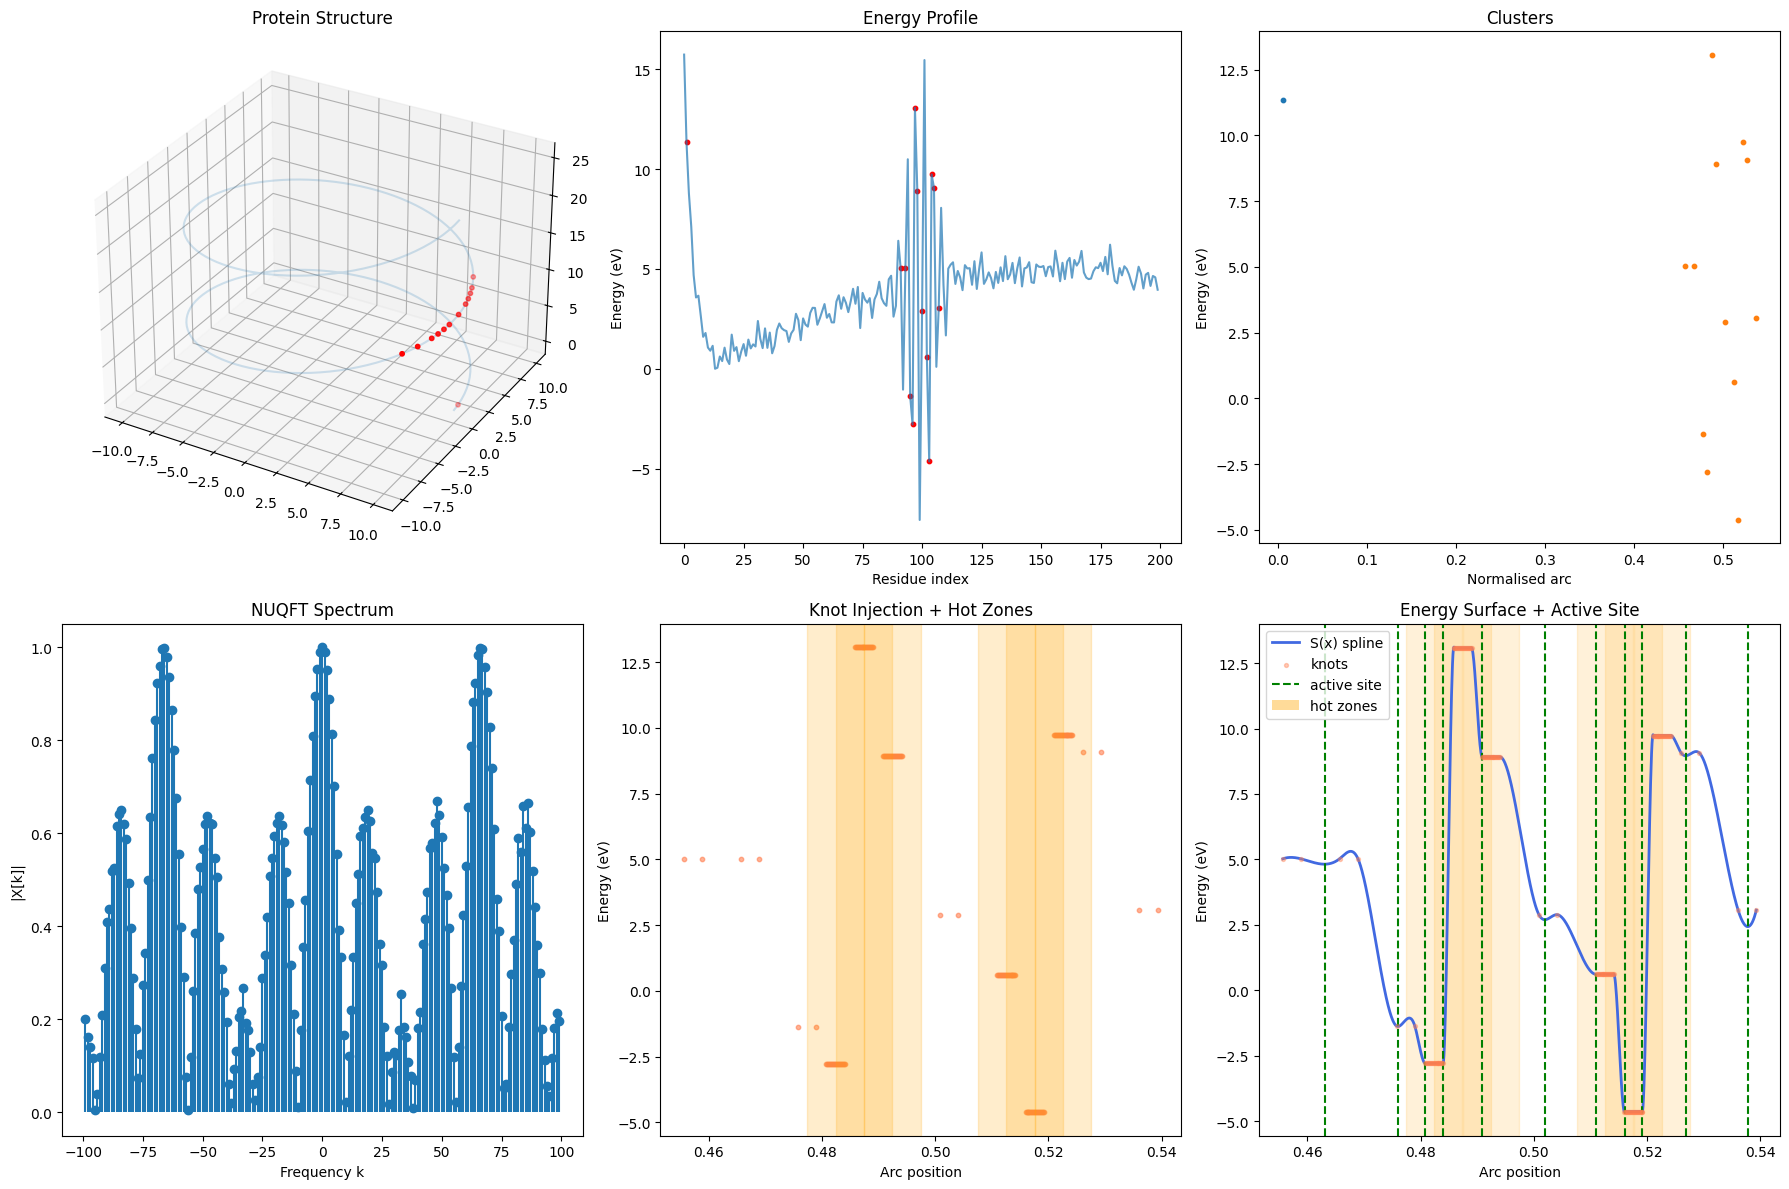

In [ ]:
def run():
    from scipy.signal import argrelmin

    gen = ProteinDataGenerator()
    pos, E, arc = gen.generate()

    sampler = SparseSampler()
    sparse = sampler.sample(pos, E, arc)

    clusterer = Clusterer()
    clusters = clusterer.cluster(sparse, arc)
    cluster = max(clusters, key=lambda c: len(c.t))
    t = cluster.t
    e = cluster.energies

    k_vals, X = quantum_nuqft(t, e)

    kp, ke, hot_zone_coords = knot_injection(t, e)

    x_fine, y_fine = fit_and_evaluate(kp, ke)

    local_minima = argrelmin(y_fine, order=10)[0]
    active_site_coords = x_fine[local_minima]
    active_site_energies = y_fine[local_minima]

    print("=" * 40)
    print(f"  Active sites found: {len(active_site_coords)}")
    for i, (coord, energy) in enumerate(zip(active_site_coords, active_site_energies)):
        print(f"  [{i+1}] coord: {coord:.4f}  energy: {energy:.6f} eV")
    print(f"  Hot zones detected: {len(hot_zone_coords)}")
    print("=" * 40)

    visualize(pos, E, sparse, clusters, k_vals, X, kp, ke, x_fine, y_fine, active_site_coords, hot_zone_coords)


run()